# Shiller CAPE distribution and valuation-risk validation

This notebook validates CAPE as the valuation component of the composite indicator. It follows the VIX/SKEW analysis order: inspect the raw distribution first, diagnose the long-run trend, apply the pre-specified transformation, test the final Z distribution, and show every intermediate value for the latest observation. It does not test trading rules.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.market_risk.cape import compute_cape_risk_frame

SOURCE_URL = 'https://www.multpl.com/shiller-pe/table/by-month'
WINDOW = 120
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 1. Data

Multpl's monthly Shiller PE table is parsed into one observation per calendar month. If the source contains more than one row in a month, the latest dated row is retained. The latest row is labelled provisional when it belongs to the current, incomplete month; it remains visible because the production indicator is intended to update as new observations arrive.

In [2]:
raw = pd.read_html(SOURCE_URL)[0].iloc[:, :2].copy()
raw.columns = ['Date', 'CAPE']
raw['Date'] = pd.to_datetime(raw['Date'], errors='coerce')
raw['CAPE'] = pd.to_numeric(
    raw['CAPE'].astype(str).str.replace(',', '', regex=False).str.extract(r'([0-9]+(?:\.[0-9]+)?)')[0],
    errors='coerce',
)
raw = raw.dropna().sort_values('Date')
raw['Month'] = raw['Date'].dt.to_period('M')
duplicate_month_rows = int(raw.duplicated('Month', keep=False).sum())
monthly = raw.drop_duplicates('Month', keep='last').set_index('Date')[['CAPE']]
today = pd.Timestamp.today().normalize()
latest_is_provisional = monthly.index[-1].to_period('M') == today.to_period('M')

pd.Series({
    'source': SOURCE_URL,
    'first_date': monthly.index.min().date(),
    'last_date': monthly.index.max().date(),
    'observations': len(monthly),
    'duplicate_month_rows_before_dedup': duplicate_month_rows,
    'missing_months_in_calendar_range': len(pd.period_range(monthly.index.min(), monthly.index.max(), freq='M')) - len(monthly),
    'latest_status': 'provisional current month' if latest_is_provisional else 'completed month',
})

source                               https://www.multpl.com/shiller-pe/table/by-month
first_date                                                                 1871-02-01
last_date                                                                  2026-07-29
observations                                                                     1866
duplicate_month_rows_before_dedup                                                   2
missing_months_in_calendar_range                                                    0
latest_status                                               provisional current month
dtype: object

## 2. Raw distribution

The unadjusted distribution answers the first question directly: where CAPE has historically been concentrated. Its percentile is descriptive, but it mixes today's valuation regime with the much lower levels common early in the sample. That is why an absolute all-history threshold can repeatedly call a structurally higher regime expensive.

,raw_CAPE
count,"1,866.0000"
mean,17.3996
std,7.4877
min,4.7800
1%,5.5895
5%,8.0500
25%,11.7525
50%,16.1100
75%,21.0700
95%,32.5750


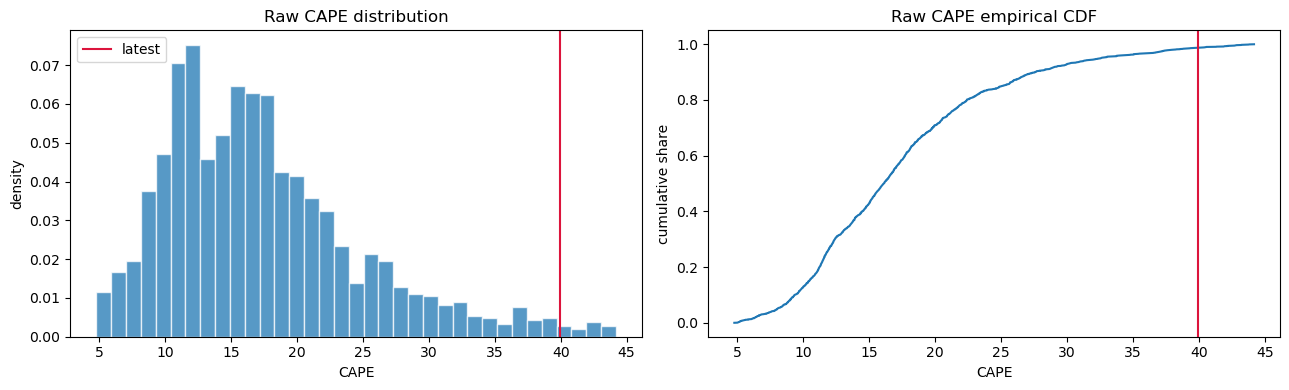

In [3]:
raw_summary = monthly['CAPE'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
raw_summary.loc['skew'] = monthly['CAPE'].skew()
raw_summary.loc['excess_kurtosis'] = monthly['CAPE'].kurt()
raw_summary.loc['lag1_autocorrelation'] = monthly['CAPE'].autocorr(1)
raw_summary.loc['latest_percentile_pct'] = monthly['CAPE'].rank(pct=True).iloc[-1] * 100
display(raw_summary.to_frame('raw_CAPE'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(monthly['CAPE'], bins=35, density=True, alpha=.75, edgecolor='white')
axes[0].axvline(monthly['CAPE'].iloc[-1], color='crimson', label='latest')
axes[0].set(title='Raw CAPE distribution', xlabel='CAPE', ylabel='density')
axes[0].legend()
x = np.sort(monthly['CAPE'].to_numpy())
axes[1].plot(x, np.arange(1, len(x) + 1) / len(x))
axes[1].axvline(monthly['CAPE'].iloc[-1], color='crimson')
axes[1].set(title='Raw CAPE empirical CDF', xlabel='CAPE', ylabel='cumulative share')
plt.tight_layout()

## 3. Long-run trend diagnosis

Annual mean and median are estimated separately on the log scale. The annualized slopes quantify the historical drift without assuming that one fitted exponential curve is the correct live benchmark. The fixed trend is therefore a diagnostic only: it uses the full sample retrospectively and is not the official adjustment.

,annualized_growth_pct,r_squared,slope_p_value
series,,,
mean,0.4465,0.2318,0.0000
median,0.4480,0.2317,0.0000


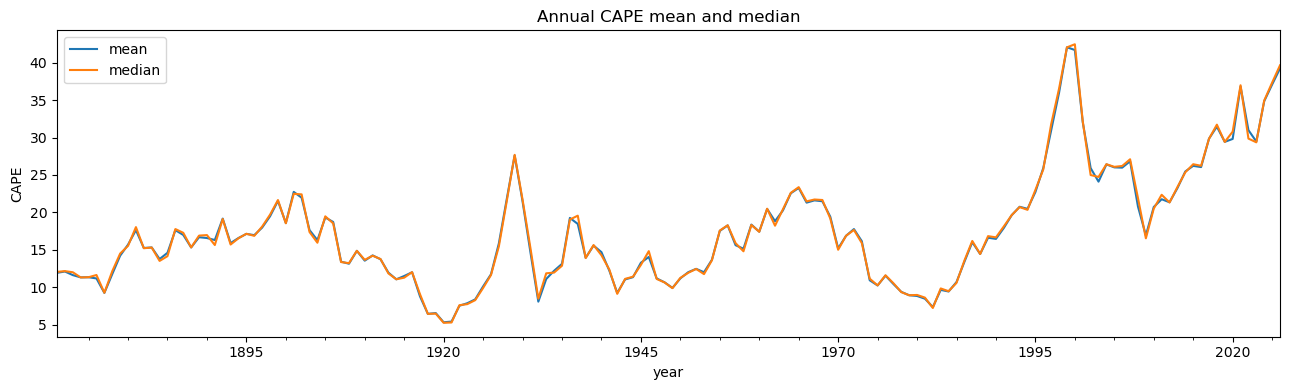

In [4]:
annual = monthly['CAPE'].resample('YE').agg(['mean', 'median']).dropna()
trend_rows = []
for metric in ['mean', 'median']:
    fit = stats.linregress(annual.index.year, np.log(annual[metric]))
    trend_rows.append({
        'series': metric,
        'annualized_growth_pct': (np.exp(fit.slope) - 1) * 100,
        'r_squared': fit.rvalue ** 2,
        'slope_p_value': fit.pvalue,
    })
trend_summary = pd.DataFrame(trend_rows).set_index('series')
display(trend_summary)

ax = annual.plot(figsize=(13, 4), title='Annual CAPE mean and median')
ax.set(ylabel='CAPE', xlabel='year')
plt.tight_layout()

## 4. Official two-stage transformation

Stage 1 measures `(CAPE - trailing 120-month CAPE mean) / trailing mean`. Stage 2 compares that deviation with the trailing 120-month mean and sample standard deviation of prior deviations. The result answers: how unusual is today's distance from its local CAPE level relative to the recent distribution of such distances? The horizon is pre-specified because CAPE itself is built from ten years of real earnings; it is not selected by searching for the best backtest.

In [5]:
cape = compute_cape_risk_frame(monthly, value_col='CAPE', window=WINDOW)
valid = cape.dropna(subset=['Z_Score']).copy()
valid['Empirical_Z_Percentile'] = valid['Z_Score'].rank(pct=True)
valid[['CAPE', 'CAPE_10Y_Avg', 'CAPE_Deviation', 'Dev_10Y_Avg', 'Dev_10Y_Std', 'Z_Score', 'Normal_Risk_Score']].tail()

,CAPE,CAPE_10Y_Avg,CAPE_Deviation,Dev_10Y_Avg,Dev_10Y_Std,Z_Score,Normal_Risk_Score
Date,,,,,,,
2026-03-01,37.0400,31.9307,0.1600,0.1912,0.1193,-0.2618,0.3967
2026-04-01,38.1500,32.0327,0.1910,0.1917,0.1191,-0.0063,0.4975
2026-05-01,40.2800,32.1543,0.2527,0.1928,0.1191,0.5030,0.6925
2026-06-01,40.5000,32.2764,0.2548,0.1939,0.1191,0.5116,0.6955
2026-07-29,39.9300,32.3867,0.2329,0.1944,0.1191,0.3232,0.6267


## 5. Final Z distribution

A rolling Z-score is not guaranteed to follow a standard normal distribution. The table therefore compares observed coverage and one-sided tail frequencies with the theoretical normal values. Serial dependence is also reported because adjacent monthly rolling estimates overlap heavily. Sigma remains meaningful as a local standardized distance, and the normal CDF gives its exact theoretical cumulative-probability mapping: `+1 sigma = 84.13%` and `+2 sigma = 97.72%`.

,final_Z
n,"1,628.0000"
mean,0.0539
std,1.3639
skew,0.2243
excess_kurtosis,-0.5654
lag1_autocorrelation,0.9836
jarque_bera_p_value,0.0000


,empirical_within_pct,normal_within_pct,empirical_upper_pct,normal_upper_pct,empirical_lower_pct,normal_lower_pct
sigma,,,,,,
1,50.9828,68.2689,26.5971,15.8655,22.4201,15.8655
2,83.9681,95.4500,10.3808,2.2750,5.6511,2.2750
3,98.7715,99.7300,0.8600,0.1350,0.3686,0.1350


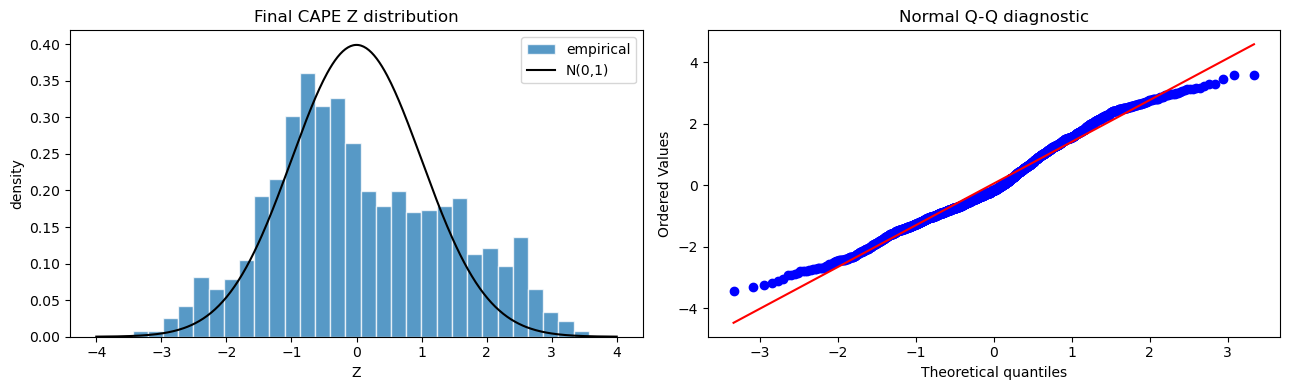

In [6]:
z = valid['Z_Score']
shape = pd.Series({
    'n': len(z), 'mean': z.mean(), 'std': z.std(), 'skew': z.skew(),
    'excess_kurtosis': z.kurt(), 'lag1_autocorrelation': z.autocorr(1),
    'jarque_bera_p_value': stats.jarque_bera(z).pvalue,
})
coverage = []
for sigma in [1, 2, 3]:
    coverage.append({
        'sigma': sigma,
        'empirical_within_pct': (z.abs() <= sigma).mean() * 100,
        'normal_within_pct': (stats.norm.cdf(sigma) - stats.norm.cdf(-sigma)) * 100,
        'empirical_upper_pct': (z > sigma).mean() * 100,
        'normal_upper_pct': stats.norm.sf(sigma) * 100,
        'empirical_lower_pct': (z < -sigma).mean() * 100,
        'normal_lower_pct': stats.norm.cdf(-sigma) * 100,
    })
display(shape.to_frame('final_Z'))
display(pd.DataFrame(coverage).set_index('sigma'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(z, bins=30, density=True, alpha=.75, edgecolor='white', label='empirical')
grid = np.linspace(-4, 4, 400)
axes[0].plot(grid, stats.norm.pdf(grid), color='black', label='N(0,1)')
axes[0].set(title='Final CAPE Z distribution', xlabel='Z', ylabel='density')
axes[0].legend()
stats.probplot(z, dist='norm', plot=axes[1])
axes[1].set_title('Normal Q-Q diagnostic')
plt.tight_layout()

## 6. Current reading and decision

The final table exposes every production input rather than only the 0–1 score. Retain the two-stage 120-month calculation when the objective is local relative valuation. Use the Z-score for sigma-language and its normal-CDF value as the corresponding bounded theoretical cumulative probability for cross-indicator aggregation. Report the empirical Z rank separately.

In [7]:
latest = valid.iloc[-1]
pd.Series({
    'observation_date': valid.index[-1].date(),
    'observation_status': 'provisional current month' if latest_is_provisional else 'completed month',
    'raw_CAPE': latest['CAPE'],
    'CAPE_120m_mean': latest['CAPE_10Y_Avg'],
    'relative_deviation': latest['CAPE_Deviation'],
    'deviation_120m_mean': latest['Dev_10Y_Avg'],
    'deviation_120m_sample_std': latest['Dev_10Y_Std'],
    'final_Z': latest['Z_Score'],
    'normal_CDF_score': latest['Normal_Risk_Score'],
    'empirical_Z_percentile': latest['Empirical_Z_Percentile'],
})

observation_date                            2026-07-29
observation_status           provisional current month
raw_CAPE                                       39.9300
CAPE_120m_mean                                 32.3867
relative_deviation                              0.2329
deviation_120m_mean                             0.1944
deviation_120m_sample_std                       0.1191
final_Z                                         0.3232
normal_CDF_score                                0.6267
empirical_Z_percentile                          0.6100
dtype: object